In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.tools import diff
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
plt.rc("figure", figsize=(16, 5))

In this area, we shall be covering the following recipes:

• Forecasting time series data using auto_arima

• Forecasting time series data using Facebook prophet

• Forecasting time series data using VAR

### 1. Forecasting time series data using auto_arima

In [2]:
import pmdarima as pm

In [3]:
path = Path('../../../Code in Zip/Time-Series-Analysis-with-Python-Cookbook-main/datasets/Ch11')

milk = pd.read_csv(path / 'milk_production.csv', index_col='month', parse_dates=True)

milk.head()

,production
month,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


In [4]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(milk, test_size=.10, shuffle=False)

train, test = pm.model_selection.train_test_split(milk, test_size=.10)

print(f'Train: {train.shape}')
print(f'Test: {test.shape}')

Train: (151, 1)
Test: (17, 1)


You will use the auto_arima function from pmdarima to optimize and find the best configuration for your SARIMA model. Prior knowledge about the milk data is key to obtaining the best results from auto_arima. You know the data has a seasonal pattern, so you will need to provide values for the two parameters: seasonal=True and m=12 (the number of periods in a season). If these values are not set, the model will only search for the non-seasonal orders (p, d, q).

In [5]:
auto_model = pm.auto_arima(train, seasonal=True, m=12, test='adf', stepwise=True)

auto_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  151
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -475.008
Date:                            Thu, 23 Jan 2025   AIC                            956.016
Time:                                    11:55:27   BIC                            964.798
Sample:                                01-01-1962   HQIC                           959.585
                                     - 07-01-1974                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2714      0.082     -3.326      0.001      -0.431      -0.111
ma.S.L12      -0.6233      0.079     -7.908      0.000      -0.778      -0.469
sigma2        54.7638      5.498      9.960      0.000      43.987      65.540
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                31.78
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):               1.22   Skew:                             0.74
Prob(H) (two-sided):                  0.50   Kurtosis:                         4.83
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [6]:
auto_model = pm.auto_arima(train, seasonal=True, m=12, test='adf', stepwise=True, trace=True)

auto_model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=961.878, Time=2.97 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1005.341, Time=0.11 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=971.814, Time=0.62 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=956.016, Time=0.90 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=996.508, Time=0.15 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=957.982, Time=1.32 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=957.967, Time=2.75 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=971.938, Time=0.40 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=960.016, Time=1.43 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=964.474, Time=0.81 sec
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=957.884, Time=0.64 sec
 ARIMA(0,1,2)(0,1,1)[12]             : AIC=957.783, Time=2.12 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=956.436, Time=0.66 sec
 ARIMA(1,1,2)(0,1,1)[12]             : AIC=959.701, Time=1.10 sec
 ARIMA(0,1,1)(0,1,1)[12] interce

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  151
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -475.008
Date:                            Thu, 23 Jan 2025   AIC                            956.016
Time:                                    11:55:44   BIC                            964.798
Sample:                                01-01-1962   HQIC                           959.585
                                     - 07-01-1974                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2714      0.082     -3.326      0.001      -0.431      -0.111
ma.S.L12      -0.6233      0.079     -7.908      0.000      -0.778      -0.469
sigma2        54.7638      5.498      9.960      0.000      43.987      65.540
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                31.78
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):               1.22   Skew:                             0.74
Prob(H) (two-sided):                  0.50   Kurtosis:                         4.83
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [7]:
auto_model = pm.auto_arima(train, seasonal=True, m=12, test='adf', 
                           information_criterion='bic', stepwise=True,
                           trace=True)

auto_model.summary()

Performing stepwise search to minimize bic
 ARIMA(2,1,2)(1,1,1)[12]             : BIC=982.369, Time=3.42 sec
 ARIMA(0,1,0)(0,1,0)[12]             : BIC=1008.269, Time=0.04 sec
 ARIMA(1,1,0)(1,1,0)[12]             : BIC=980.596, Time=0.74 sec
 ARIMA(0,1,1)(0,1,1)[12]             : BIC=964.798, Time=0.44 sec
 ARIMA(0,1,1)(0,1,0)[12]             : BIC=1002.362, Time=0.12 sec
 ARIMA(0,1,1)(1,1,1)[12]             : BIC=969.691, Time=0.70 sec
 ARIMA(0,1,1)(0,1,2)[12]             : BIC=969.676, Time=1.25 sec
 ARIMA(0,1,1)(1,1,0)[12]             : BIC=980.720, Time=0.67 sec
 ARIMA(0,1,1)(1,1,2)[12]             : BIC=974.652, Time=3.23 sec
 ARIMA(0,1,0)(0,1,1)[12]             : BIC=970.329, Time=0.28 sec
 ARIMA(1,1,1)(0,1,1)[12]             : BIC=969.593, Time=0.57 sec
 ARIMA(0,1,2)(0,1,1)[12]             : BIC=969.493, Time=1.59 sec
 ARIMA(1,1,0)(0,1,1)[12]             : BIC=965.218, Time=1.51 sec
 ARIMA(1,1,2)(0,1,1)[12]             : BIC=974.337, Time=1.96 sec
 ARIMA(0,1,1)(0,1,1)[12] interc

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  151
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -475.008
Date:                            Thu, 23 Jan 2025   AIC                            956.016
Time:                                    11:56:02   BIC                            964.798
Sample:                                01-01-1962   HQIC                           959.585
                                     - 07-01-1974                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2714      0.082     -3.326      0.001      -0.431      -0.111
ma.S.L12      -0.6233      0.079     -7.908      0.000      -0.778      -0.469
sigma2        54.7638      5.498      9.960      0.000      43.987      65.540
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                31.78
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):               1.22   Skew:                             0.74
Prob(H) (two-sided):                  0.50   Kurtosis:                         4.83
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

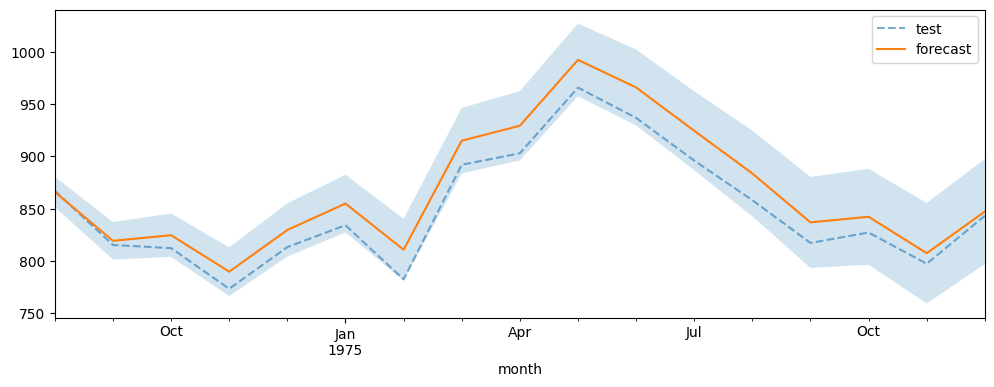

In [8]:
n = test.shape[0]
forecast, conf_interval = auto_model.predict(n_periods=n, return_conf_int=True)
lower_ci, upper_ci = zip(*conf_interval)

index = test.index
ax = test.plot(style='--', alpha=0.6, figsize=(12,4))
pd.Series(forecast, index=index).plot(style='-', ax=ax)
plt.fill_between(index, lower_ci, upper_ci, alpha=0.2)
plt.legend(['test','forecast']); plt.show()

The auto_arima function from the pmdarima library is a wrapper for the statsmodels SARIMAX class. auto_arima intelligently attempts to automate the process of optimizing the training process to find the best model and parameters. There are three ways to do so:

• The naive brute-force grid search method (full search)

• Random grid search

• The stepwise search algorithm

This is controlled by the stepwise parameter, which defaults to ***True***.

In [9]:
sum(forecast) == sum(conf_interval.mean(axis=1))

True

The pmdarima library offers a plethora of useful functions to help you make informed decisions so that you can understand the data you are working with.

For example, the ndiff function performs stationarity tests to determine the differencing order, d, to make the time series stationary. The tests include the Augmented Dickey-Fuller (adf) test, the Kwiatkowski–Phillips–Schmidt–Shin (kpss) test, and the Phillips-Perron (pp) test.

Similarly, the nsdiff function helps estimate the number of seasonal differencing orders (D ) that are needed. The implementation covers two tests – the Osborn-Chui-Smith-Birchenhall (ocsb) and Canova-Hansen (ch) tests:

In [10]:
from pmdarima.arima.utils import ndiffs, nsdiffs


n_adf = ndiffs(milk, test='adf')
# KPSS test (the default in auto_arima):
n_kpss = ndiffs(milk, test='kpss')
n_pp = ndiffs(milk, test='pp')
n_ch = nsdiffs(milk, test='ocsb', m=10, max_D=12,)
n_ocsb = nsdiffs(milk, test='ch' , m=10, max_D=12,)

In [11]:
model = pm.auto_arima(
    train,
    seasonal=True,
    with_intercept=True,
    d=1,
    max_d=2,
    start_p=0, max_p=2,
    start_q=0, max_q=2,
    m=12,
    D=1,
    max_D=2,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    information_criterion='aic',
    stepwise=False,
    out_of_sample_siz=25,
    test = 'kpss',
    score='mape',
    trace=True
)

 ARIMA(0,1,0)(0,1,0)[12] intercept   : AIC=1007.319, Time=0.04 sec
 ARIMA(0,1,0)(0,1,1)[12] intercept   : AIC=966.470, Time=0.78 sec
 ARIMA(0,1,0)(0,1,2)[12] intercept   : AIC=968.422, Time=1.81 sec
 ARIMA(0,1,0)(1,1,0)[12] intercept   : AIC=983.036, Time=0.81 sec
 ARIMA(0,1,0)(1,1,1)[12] intercept   : AIC=968.438, Time=0.51 sec
 ARIMA(0,1,0)(1,1,2)[12] intercept   : AIC=970.470, Time=1.17 sec
 ARIMA(0,1,0)(2,1,0)[12] intercept   : AIC=973.451, Time=0.97 sec
 ARIMA(0,1,0)(2,1,1)[12] intercept   : AIC=968.640, Time=1.45 sec
 ARIMA(0,1,0)(2,1,2)[12] intercept   : AIC=inf, Time=8.08 sec
 ARIMA(0,1,1)(0,1,0)[12] intercept   : AIC=998.468, Time=0.17 sec
 ARIMA(0,1,1)(0,1,1)[12] intercept   : AIC=958.000, Time=1.00 sec
 ARIMA(0,1,1)(0,1,2)[12] intercept   : AIC=959.947, Time=1.40 sec
 ARIMA(0,1,1)(1,1,0)[12] intercept   : AIC=973.934, Time=1.03 sec
 ARIMA(0,1,1)(1,1,1)[12] intercept   : AIC=959.963, Time=1.05 sec
 ARIMA(0,1,1)(1,1,2)[12] intercept   : AIC=962.000, Time=1.87 sec
 ARIMA(0,1,1)

In [12]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  151
Model:             SARIMAX(2, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -472.969
Date:                            Thu, 23 Jan 2025   AIC                            957.937
Time:                                    11:59:10   BIC                            975.501
Sample:                                01-01-1962   HQIC                           965.075
                                     - 07-01-1974                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0460      0.621     -0.074      0.941      -1.263       1.171
ar.L1         -1.1997      0.092    -13.044      0.000      -1.380      -1.019
ar.L2         -0.3072      0.098     -3.137      0.002      -0.499      -0.115
ma.L1          0.9585      0.066     14.616      0.000       0.830       1.087
ma.S.L12      -0.6124      0.084     -7.289      0.000      -0.777      -0.448
sigma2        52.8038      5.479      9.637      0.000      42.065      63.543
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                41.88
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               1.28   Skew:                             0.82
Prob(H) (two-sided):                  0.41   Kurtosis:                         5.14
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

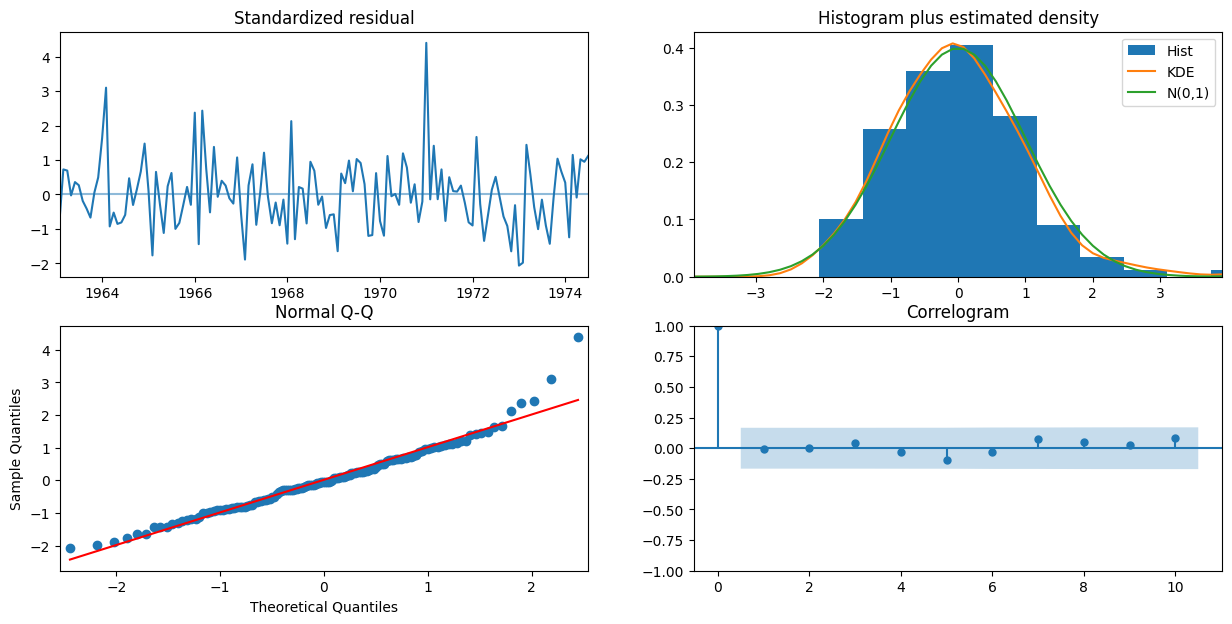

In [13]:
model.plot_diagnostics(figsize=(15,7)); plt.show()

In [14]:
model.out_of_sample_size

0

In [15]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  151
Model:             SARIMAX(2, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -472.969
Date:                            Thu, 23 Jan 2025   AIC                            957.937
Time:                                    11:59:12   BIC                            975.501
Sample:                                01-01-1962   HQIC                           965.075
                                     - 07-01-1974                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0460      0.621     -0.074      0.941      -1.263       1.171
ar.L1         -1.1997      0.092    -13.044      0.000      -1.380      -1.019
ar.L2         -0.3072      0.098     -3.137      0.002      -0.499      -0.115
ma.L1          0.9585      0.066     14.616      0.000       0.830       1.087
ma.S.L12      -0.6124      0.084     -7.289      0.000      -0.777      -0.448
sigma2        52.8038      5.479      9.637      0.000      42.065      63.543
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                41.88
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               1.28   Skew:                             0.82
Prob(H) (two-sided):                  0.41   Kurtosis:                         5.14
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### 2. Forecasting time series data using Facebook Prophet

The Prophet algorithm is an additive regression model that can handle non-linear trends
and works well with strong seasonal effects. The algorithm decomposes a time series into
three main components: trend, seasonality, and holidays. The model can be written
as follows:

            y(𝑡) = g(𝑡) + s(𝑡) + h(𝑡) + ϵ𝑡

Here, g(𝑡) is the trend function, s(𝑡) represents the periodic seasonality function, h(𝑡) covers effects of holidays, and ϵ𝑡 is the error term (residual).

The algorithm uses Bayesian inferencing to automate many aspects of tuning the model and finding the optimized values for each component. Behind the scenes, Prophet uses **Stan**, a library for Bayesian inferencing, through the **PyStan** library as the Python
interface to Stan.

In [16]:
from prophet import Prophet

milk = pd.read_csv(path / 'milk_production.csv', parse_dates=['month'])

milk.columns = ['ds','y']
milk.tail()

,ds,y
163,1975-08-01,858
164,1975-09-01,817
165,1975-10-01,827
166,1975-11-01,797
167,1975-12-01,843


In [17]:
# Split the data
idx = round(len(milk) * 0.90)
train = milk[:idx]
test = milk[idx:]
print(f'Train: {train.shape}')
print(f'Test: {test.shape}')

Train: (151, 2)
Test: (17, 2)


<Axes: title={'center': 'Monthly milk production'}, xlabel='ds'>

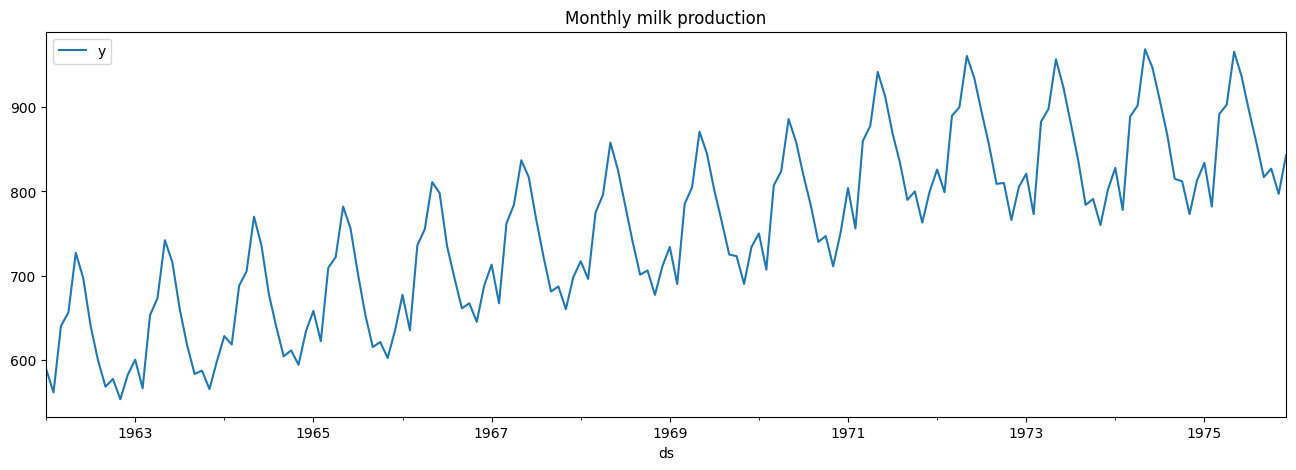

In [18]:
milk.set_index('ds').plot(title="Monthly milk production")

In [19]:
model = Prophet().fit(train)

11:59:14 - cmdstanpy - INFO - Chain [1] start processing
11:59:14 - cmdstanpy - INFO - Chain [1] done processing


In [20]:
model.seasonalities

OrderedDict([('yearly',
              {'period': 365.25,
               'fourier_order': 10,
               'prior_scale': 10.0,
               'mode': 'additive',
               'condition_name': None})])

In [21]:
model.component_modes

{'additive': ['yearly',
  'additive_terms',
  'extra_regressors_additive',
  'holidays'],
 'multiplicative': ['multiplicative_terms', 'extra_regressors_multiplicative']}

Some setup needs to be done before you can use the model to make predictions. Use the make_future_dataframe method to extend the train DataFrame forward for a specific number of periods and at a specified frequency:

In [22]:
future = model.make_future_dataframe(len(test), freq='MS')

In [23]:
future.tail()

,ds
163,1975-08-01
164,1975-09-01
165,1975-10-01
166,1975-11-01
167,1975-12-01


This extends the training data by 17 months (the number of periods in the test set). In total, you should have the exact number of periods that are in the milk DataFrame (train and test). The frequency is set to month start with freq='MS'. The future object only contains one column, ds, of the datetime64[ns] type, which is used to populate the predicted values:

In [24]:
len(milk) == len(future)

True

Now, use the predict method to take the future DataFrame and make predictions. The result will be a DataFrame that's the same length as forecast but now with additional columns:

In [25]:
forecast = model.predict(future)
forecast.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms',
       'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat'],
      dtype='object')

In [26]:
cols = ['ds', 'yhat', 'yhat_lower', 'yhat_upper']

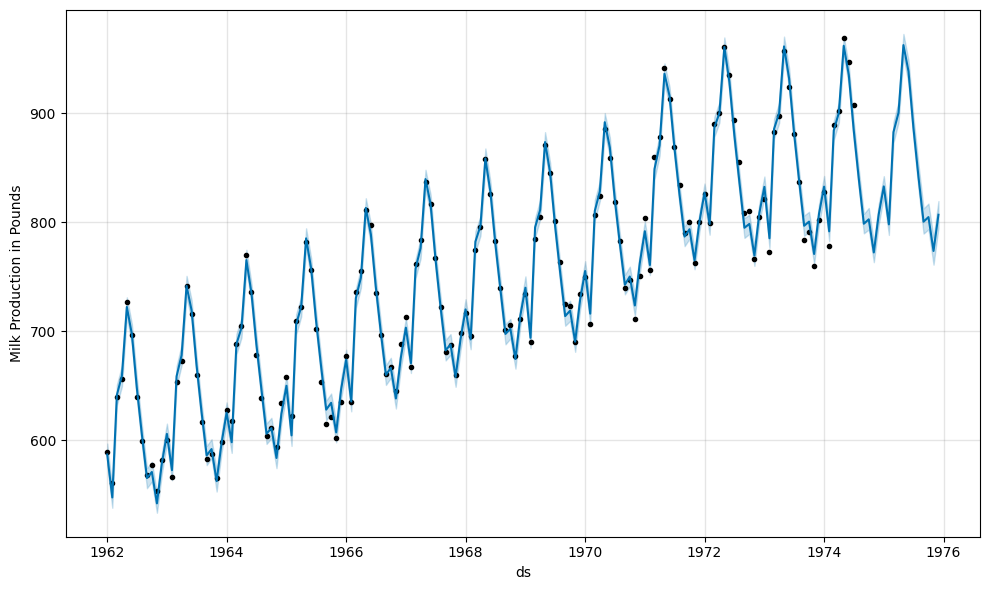

In [27]:
model.plot(forecast, ylabel='Milk Production in Pounds'); plt.show()

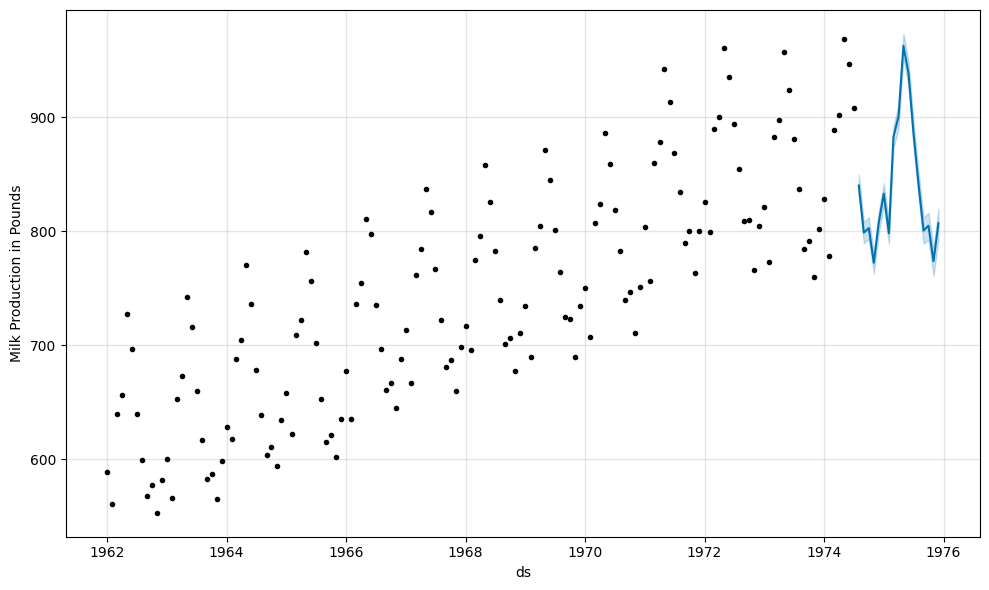

In [28]:
predicted = model.predict(test)
model.plot(predicted, ylabel='Milk Production in Pounds'); plt.show()

In [29]:
predicted.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1974-08-01,854.317989,831.048450,849.778619,854.317989,854.317989,-14.168785,-14.168785,-14.168785,-14.168785,-14.168785,-14.168785,0.0,0.0,0.0,840.149204
1,1974-09-01,854.447146,789.450627,807.892364,854.313709,854.565187,-55.712688,-55.712688,-55.712688,-55.712688,-55.712688,-55.712688,0.0,0.0,0.0,798.734458
2,1974-10-01,854.572136,793.441080,812.266986,854.195052,854.926216,-51.800679,-51.800679,-51.800679,-51.800679,-51.800679,-51.800679,0.0,0.0,0.0,802.771457
3,1974-11-01,854.701292,762.895419,781.277479,854.005674,855.373954,-82.336627,-82.336627,-82.336627,-82.336627,-82.336627,-82.336627,0.0,0.0,0.0,772.364666
4,1974-12-01,854.826282,797.994441,816.885113,853.668456,855.842445,-47.347332,-47.347332,-47.347332,-47.347332,-47.347332,-47.347332,0.0,0.0,0.0,807.478950


In [30]:
predicted.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms',
       'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat'],
      dtype='object')

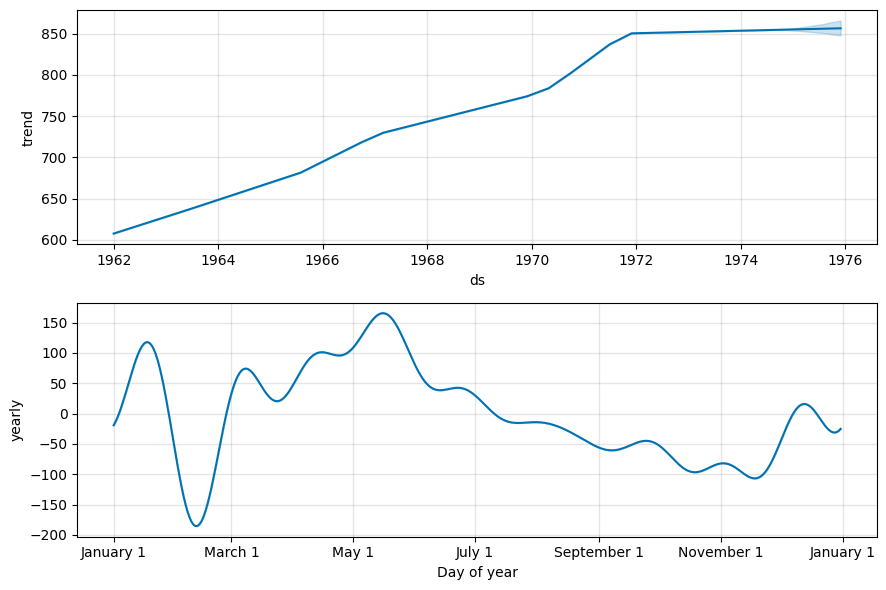

In [31]:
model.plot_components(forecast); plt.show()

The shaded area in the trend plot represents the uncertainty interval for estimatingthe trend. The data is stored in the trend_lower and trend_upper columns of the forecast DataFrame.

Finally, compare with out-of-sample data (the test data) to see how well the model performs:

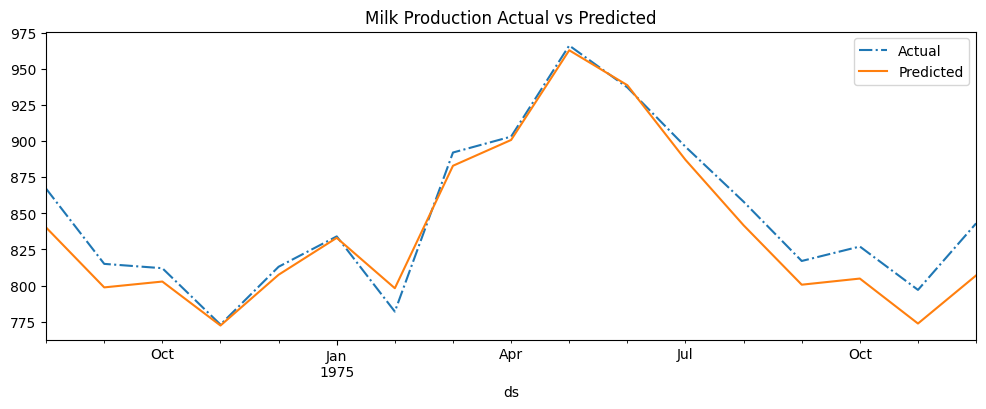

In [32]:
ax = test.plot(x='ds', y='y', label='Actual', style='-.', figsize=(12, 4))
predicted.plot(x='ds', y='yhat', label='Predicted', ax=ax)
plt.title('Milk Production Actual vs Predicted'); plt.show()

Notice that for the highly seasonal milk production data, the model did a great job. Generally, Prophet shines when it's working with strong seasonal time series data.

***yearly_seasonality***, ***weekly_seasonality***, and ***daily_seasonality*** are set to auto by default, this allows Prophet to determine which ones to turn on or off based on the data.

As per Prophet's documentation, there are three components for the uncertainty intervals
(for example, yhat_lower and yhat_upper):

• Observation noise

• Parameter uncertainty

• Future trend uncertainty

By default, the ***uncertainty_samples*** parameter is set to 1000, which is the number of simulations to estimate the uncertainty using the **Hamiltonian Monte Carlo** (**HMC**) algorithm. You can always reduce the number of samples that are simulated or set it to 0 or False to speed up the performance. If you set ***uncertainty_samples=0*** or ***uncertainty_samples=False***, the forecast's output will not contain any uncertainty interval calculations. For example, you will not have ***yhat_lower*** or ***yhat_upper***.

Prophet automatically detects changes or sudden fluctuations in the trend. Initially, it will place 25 points using the first 80% of the training data. You can change the number of changepoints with the ***n_changepoints*** parameter. Similarly, the proportion of past data to use to estimate the changepoints can be updated using ***changepoint_range***, which defaults to 0.8 (or 80%). You can observe the 25 changepoints using the changepoints attribute from the model object. The following code shows the first five:

In [33]:
changepoints = model.changepoints; changepoints.head()

5    1962-06-01
10   1962-11-01
14   1963-03-01
19   1963-08-01
24   1964-01-01
Name: ds, dtype: datetime64[ns]

This should produce a plot that contains the original time series data and the 25 potential
changepoints that indicate changes in trend:

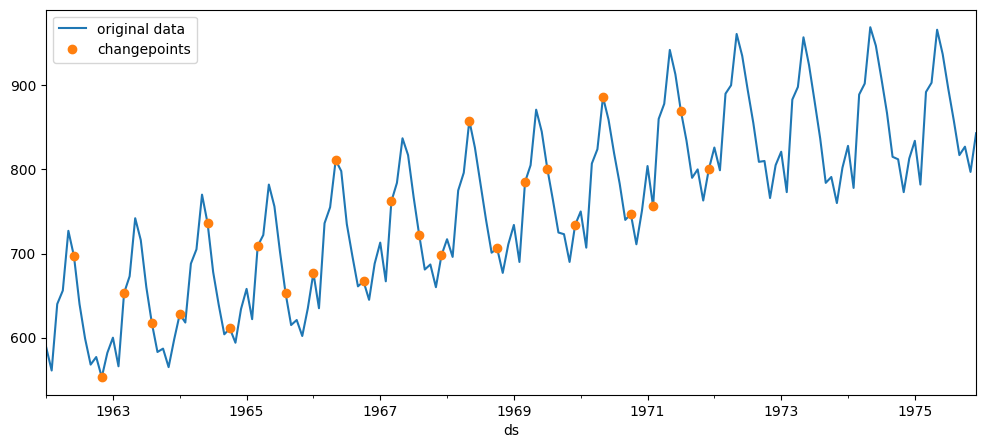

In [34]:
ax = milk.set_index('ds').plot(figsize=(12, 5))
milk.set_index('ds').loc[model.changepoints].plot(style='o', ax=ax)
plt.legend(['original data', 'changepoints']); plt.show()

These potential changepoints were estimated from the first 80% of the training data.

--------

To plot the significant changepoints that capture the impactful changes in trend, you can
use the add_changepoints_to_plot function

In [35]:
from prophet.plot import add_changepoints_to_plot

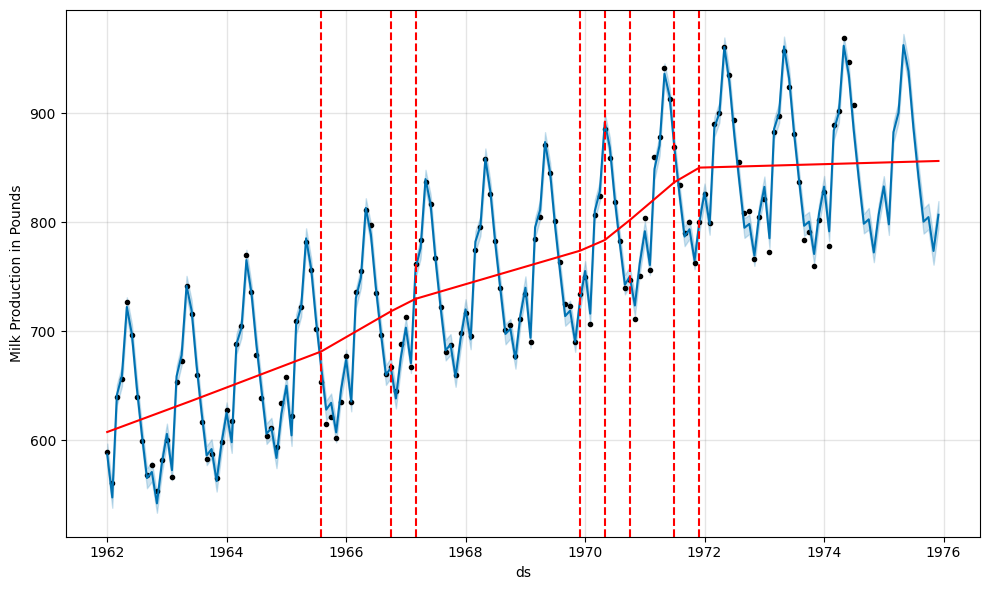

In [36]:
fig = model.plot(forecast, ylabel='Milk Production in Pounds')
add_changepoints_to_plot(fig.gca(), model, forecast); plt.show()

The plot above will be similar to its predecessor, but with the additional lines and the trend line. 8 significant changepoints are shown out of the 25. The linear trend line should be the same as the trend component.

### 3. Forecasting time series data using Vector Autoregressive (VAR)

There are other forms of multivariate time series models, including **Vector Moving Average** (**VMA**), **Vector Autoregressive Moving Average** (**VARMA**), and Vector **Autoregressive Integrated Moving Average** (**VARIMA**), that generalize other univariate models. In practice, you will find that VAR is used the most due to its simplicity. **VAR** models are very popular in economics, but you will find them being used in other areas, such as social sciences, natural sciences, and engineering.

The premise behind multivariate time series is that you can add more power to your forecast when leveraging multiple time series (or inputs variables) as opposed to a single time series (single variable). Simply put, VAR is used when you have two or more time series that have (or are assumed to have) an influence on each other's behavior. These are normally referred to as **endogenous** variables and the relationship is bi-directional. If the variables or time series are not directly related, or we do not know if there is a direct influence within the same system, we refer to them as **exogenous** variables.

A VAR model, like an AR model, assumes the stationarity of the time series variables. This means that each endogenous variable (time series) needs to be stationary. To illustrate how VAR works and the mathematical equation behind it, let's start with a simple VAR(1) with two endogenous variables, referred to as ( 𝑦𝑦1,𝑡𝑡 , 𝑦𝑦2,𝑡𝑡 ). Recall from Chapter 10, Building Univariate Time Series Models Using Statistical Methods, that an AR(1) model would take the following form:

            𝐴(1) = 𝑦𝑡 = α + θ1 𝑦𝑡−1 + ϵ𝑡

Generally, an AR(p) model is a linear model of past values of itself and the (p) parameter tells us how far back we should go. Now, assume you have two AR(1) models for two different time series data. This will look as follows:

            𝑦(1),𝑡 = α1 + θ11 𝑦(1),𝑡−1 + ϵ(1),𝑡
            𝑦(2),𝑡 = α2 + θ21 𝑦(2),𝑡−1 + ϵ(2),𝑡

However, these are two separate models that do not show any relationship or that influence each other. If we create a linear combination of the two models (the past values of itself and the past values of the other time series)

The preceding equation may seem complex, but in the end, like an AR model, it is still simply a linear function of past lags. In other words, in a VAR(1) model, you will have a linear function of lag 1 for each variable. When fitting a VAR model, as you shall see in this recipe, the **Ordinary Least Squares** (**OLS**) method is used for each equation to estimate the VAR model.

#### Exogenous versus Endogenous Variables

When you start researching more about VAR models, you will come across references to endogenous and exogenous variables. At a high level, the two are the opposite of each other and in statsmodels, you will see them referenced as endog and exog, respectively.

**Endogenous** variables are influenced by other variables within the system. In other words, we expect that a change in one's state affects the other. Sometimes, these can be referred to as dependent variables in machine learning literature. You can use the Granger causality tests to determine if there is such a relationship between multiple endogenous variables. For example, in statsmodels, you can use ***grangercausalitytests***.

On the other hand, **exogenous** variables are outside the system and do not have a direct influence on the variables. They are external influencers. Sometimes, these can be referred to as independent variables in machine learning literature.

In [37]:
import pandas_datareader.data as web
from statsmodels.tsa.api import VAR, adfuller, kpss
from statsmodels.tsa.stattools import grangercausalitytests

In [38]:
start = "01-01-1990"
end = "04-01-2022"
economic = web.FredReader(symbols=["FEDFUNDS", "unrate"], start=start, end=end).read()
file = '../../Datasets/economic.pickle'
economic.to_pickle(file)

ReadTimeout: HTTPSConnectionPool(host='fred.stlouisfed.org', port=443): Read timed out. (read timeout=30)

In [89]:
economic.isna().sum()

FEDFUNDS    0
unrate      0
dtype: int64

In [90]:
# Change the DataFrame's frequency to month start (MS) to reflect how the data is being stored:
economic.index.freq = 'MS'

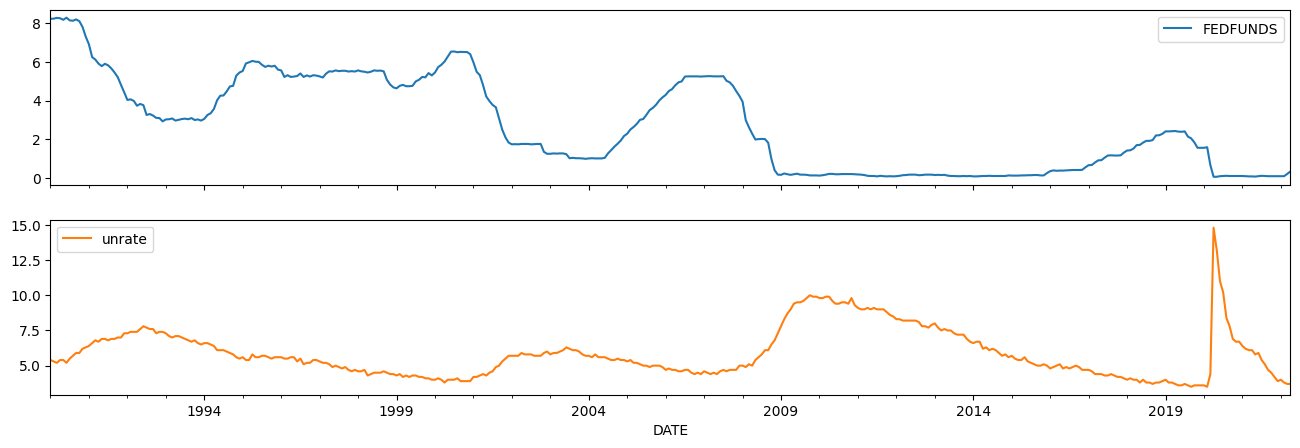

In [91]:
economic.plot(subplots=True); plt.show()

In [92]:
def check_stationarity(df):
    kps = kpss(df)
    adf = adfuller(df)
    kpss_pv, adf_pv = kps[1], adf[1]      # p-values of kpss and adf tests
    kpssh, adfh = 'Stationary', 'Non-stationary'

    if adf_pv < 0.05:
        # Reject ADF Null Hypothesis
        adfh = 'Stationary'
    if kpss_pv < 0.05:
        # Reject KPSS Null Hypothesis
        kpssh = 'Non-stationary'
        
    return (kpssh, adfh)

In [93]:
for i in economic:
    kps, adf = check_stationarity(economic[i])
    print(f'{i} adf: {adf}, kpss: {kpss}')

FEDFUNDS adf: Stationary, kpss: <function kpss at 0x75e345ed94e0>
unrate adf: Stationary, kpss: <function kpss at 0x75e345ed94e0>


In [94]:
granger = grangercausalitytests(economic[['unrate','FEDFUNDS']], maxlag=12)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.5913  , p=0.4424  , df_denom=384, df_num=1
ssr based chi2 test:   chi2=0.5959  , p=0.4402  , df=1
likelihood ratio test: chi2=0.5954  , p=0.4403  , df=1
parameter F test:         F=0.5913  , p=0.4424  , df_denom=384, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=21.7672 , p=0.0000  , df_denom=381, df_num=2
ssr based chi2 test:   chi2=44.1057 , p=0.0000  , df=2
likelihood ratio test: chi2=41.7628 , p=0.0000  , df=2
parameter F test:         F=21.7672 , p=0.0000  , df_denom=381, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=21.6011 , p=0.0000  , df_denom=378, df_num=3
ssr based chi2 test:   chi2=66.0033 , p=0.0000  , df=3
likelihood ratio test: chi2=60.9190 , p=0.0000  , df=3
parameter F test:         F=21.6011 , p=0.0000  , df_denom=378, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=16.1445 , p=0.0000  

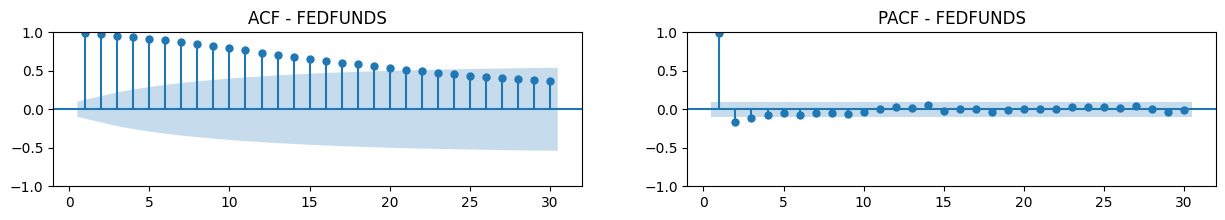

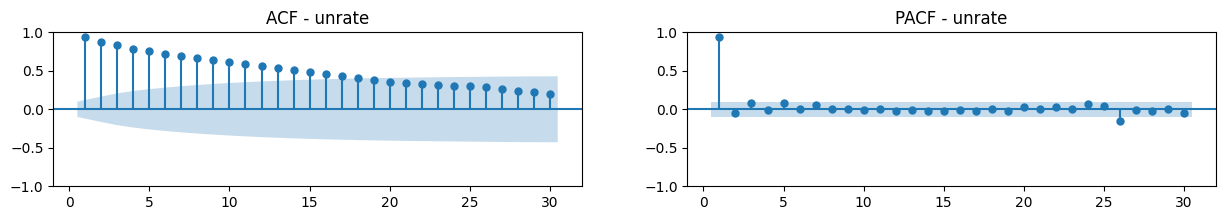

In [95]:
for col in economic.columns:
    fig, ax = plt.subplots(1,2, figsize=(15,2))
    plot_acf(economic[col], zero=False, lags=30, ax=ax[0], title=f'ACF - {col}')
    plot_pacf(economic[col], zero=False, lags=30, ax=ax[1], title=f'PACF - {col}')
    plt.show()

In [96]:
train = economic.loc[:'2019']
test = economic.loc['2020':]
print(f'Train: {len(train)}, Test: {len(test)}')

Train: 360, Test: 28


In [97]:
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()
scale.fit(train)

train_sc = pd.DataFrame(scale.transform(train), index=train.index, columns=train.columns)
test_sc = pd.DataFrame(scale.transform(test), index=test.index, columns=test.columns)

In [98]:
model = VAR(endog=train_sc, freq='MS')
res = model.select_order(maxlags=10)
res.summary()

,AIC,BIC,FPE,HQIC
0,-0.3447,-0.3227,0.7084,-0.3360
1,-9.991,-9.925,4.579e-05,-9.965
2,-10.52,-10.41,2.711e-05,-10.47
3,-10.56,-10.41,2.590e-05,-10.50
4,-10.61,-10.41*,2.468e-05,-10.53*
5,-10.61,-10.36,2.475e-05,-10.51
6,-10.62,-10.34,2.431e-05,-10.51
7,-10.66*,-10.32,2.358e-05*,-10.52
8,-10.64,-10.26,2.402e-05,-10.49
9,-10.63,-10.21,2.429e-05,-10.46


In [99]:
res.selected_orders

{'aic': 7, 'bic': 4, 'hqic': 4, 'fpe': 7}

In [100]:
results = model.fit(maxlags=7, ic='aic')

In [101]:
results.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 23, Jan, 2025
Time:                     11:03:51
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -10.3234
Nobs:                     353.000    HQIC:                  -10.5212
Log likelihood:           908.302    FPE:                2.36566e-05
AIC:                     -10.6520    Det(Omega_mle):     2.17674e-05
--------------------------------------------------------------------
Results for equation FEDFUNDS
                 coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------
const              -0.002751         0.002960           -0.929           0.353
L1.FEDFUNDS         1.438116         0.053641           26.810           0.000
L1.unrate          -0.073048         0.033805           -2.161   